In [4]:
!pip install nibabel tabulate scikit-learn pandas -q

In [5]:
import os
import glob
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Executing on: {device}")

# Locate the BraTS 2020 dataset in Kaggle's input directory
dataset_paths = glob.glob('/kaggle/input/**/MICCAI_BraTS2020_TrainingData', recursive=True)
if dataset_paths:
    train_dir = dataset_paths[0]
    patient_folders = sorted([os.path.join(train_dir, p) for p in os.listdir(train_dir) if "BraTS20_Training" in p])
    print(f"Success! Found {len(patient_folders)} multi-parametric MRI patient directories.")
else:
    print("Error: Dataset not found. Ensure the dataset is attached via the 'Add Input' button.")

Executing on: cpu
Success! Found 369 multi-parametric MRI patient directories.


In [7]:
def normalize_volume(volume):
    """Applies Z-score normalization strictly to non-zero brain voxels."""
    mask = volume > 0
    if np.any(mask):
        mean = volume[mask].mean()
        std = volume[mask].std()
        normalized = np.zeros_like(volume, dtype=np.float32)
        normalized[mask] = (volume[mask] - mean) / (std + 1e-8)
        return normalized
    return volume.astype(np.float32)

class BraTS2DDataset(Dataset):
    """Processes all 4 MRI modalities (FLAIR, T1ce, T1, T2) into a single tensor."""
    def __init__(self, patient_dirs, slice_range=(70, 100)):
        self.samples = []
        for p_dir in patient_dirs:
            p_id = os.path.basename(p_dir)
            paths = {
                'flair': os.path.join(p_dir, f"{p_id}_flair.nii"),
                't1ce':  os.path.join(p_dir, f"{p_id}_t1ce.nii"),
                't1':    os.path.join(p_dir, f"{p_id}_t1.nii"),
                't2':    os.path.join(p_dir, f"{p_id}_t2.nii"),
                'seg':   os.path.join(p_dir, f"{p_id}_seg.nii")
            }
            if os.path.exists(paths['seg']):
                for slice_idx in range(slice_range[0], slice_range[1]):
                    self.samples.append((paths, slice_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        paths, slice_idx = self.samples[idx]
        
        f_img  = nib.load(paths['flair']).dataobj[:, :, slice_idx]
        ce_img = nib.load(paths['t1ce']).dataobj[:, :, slice_idx]
        t1_img = nib.load(paths['t1']).dataobj[:, :, slice_idx]
        t2_img = nib.load(paths['t2']).dataobj[:, :, slice_idx]
        s_img  = np.array(nib.load(paths['seg']).dataobj[:, :, slice_idx], dtype=np.int64)
        
        # Stack into shape: (4, 240, 240)
        image = np.stack([
            normalize_volume(f_img), 
            normalize_volume(ce_img), 
            normalize_volume(t1_img), 
            normalize_volume(t2_img)
        ], axis=0)
        
        s_img[s_img == 4] = 3 # Remap ET label
        
        return torch.tensor(image, dtype=torch.float32), torch.tensor(s_img, dtype=torch.long), paths['flair']

# Load a small subset for rapid training and validation
train_dataset = BraTS2DDataset(patient_folders[:5], slice_range=(70, 90))
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

In [8]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, f_g, f_l, inter_ch):
        super().__init__()
        self.W_g = nn.Conv2d(f_g, inter_ch, 1)
        self.W_x = nn.Conv2d(f_l, inter_ch, 1)
        self.psi = nn.Sequential(nn.Conv2d(inter_ch, 1, 1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)
    def forward(self, g, x):
        return x * self.psi(self.relu(self.W_g(g) + self.W_x(x)))

class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = ConvBlock(4, 32)
        self.enc2 = ConvBlock(32, 64)
        self.pool = nn.MaxPool2d(2, 2)
        self.bottleneck = ConvBlock(64, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.att1 = AttentionGate(64, 64, 32)
        self.dec1 = ConvBlock(128, 64)
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.att2 = AttentionGate(32, 32, 16)
        self.dec2 = ConvBlock(64, 32)
        self.final = nn.Conv2d(32, 4, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        b = self.bottleneck(self.pool(e2))
        d1 = self.dec1(torch.cat([self.att1(g=self.up1(b), x=e2), self.up1(b)], dim=1))
        d2 = self.dec2(torch.cat([self.att2(g=self.up2(d1), x=e1), self.up2(d1)], dim=1))
        return self.final(d2)

class CompoundLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
    def forward(self, pred, target):
        ce_loss = self.ce(pred, target)
        pred_softmax = F.softmax(pred, dim=1)
        dice_loss = 0.0
        for c in range(1, 4):
            p, t = pred_softmax[:, c, :, :], (target == c).float()
            dice = (2. * (p * t).sum() + 1e-5) / (p.sum() + t.sum() + 1e-5)
            dice_loss += (1. - dice.mean())
        return ce_loss + (dice_loss / 3)

In [9]:
model = AttentionUNet().to(device)
criterion = CompoundLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

print("Starting training...")
for epoch in range(3): # Short loop for demonstration
    model.train()
    running_loss = 0.0
    for images, masks, _ in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1} | Average Loss: {running_loss/len(train_loader):.4f}")

Starting training...
Epoch 1 | Average Loss: 2.0906
Epoch 2 | Average Loss: 1.7758
Epoch 3 | Average Loss: 1.6296


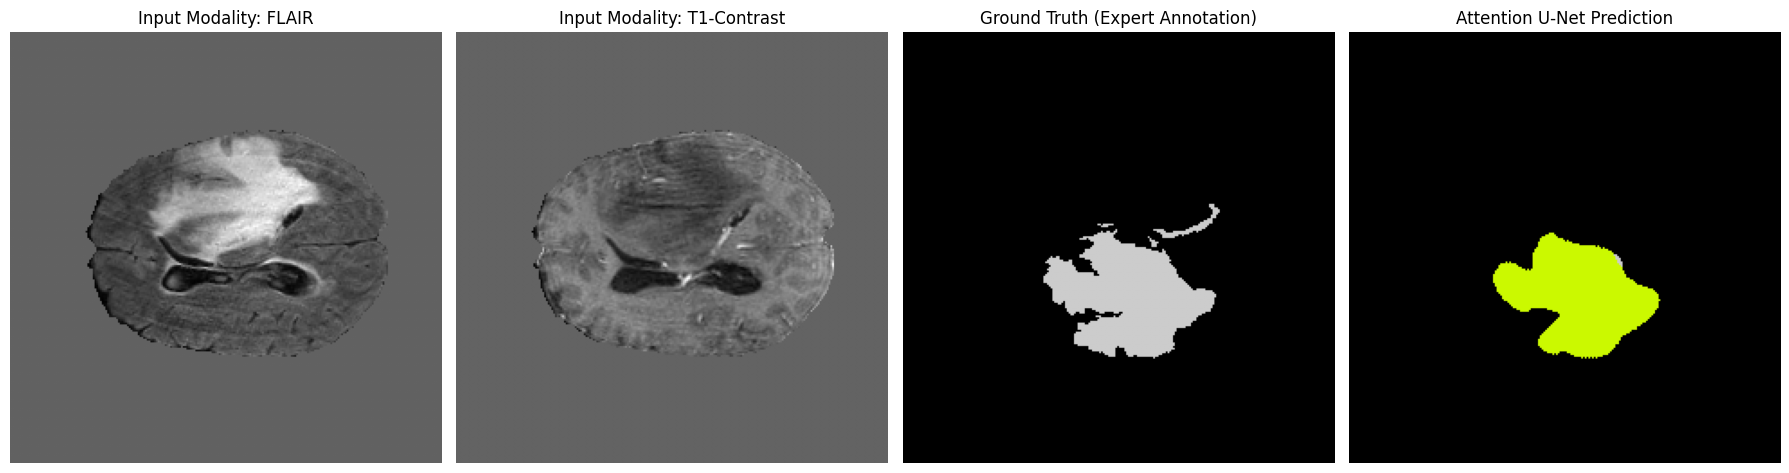

In [10]:
model.eval()

# Select a validation slice with a visible tumor
sample_img, sample_mask, nifti_path = train_dataset[15] 

input_tensor = sample_img.unsqueeze(0).to(device)

with torch.no_grad():
    raw_output = model(input_tensor)
    pred_probabilities = F.softmax(raw_output, dim=1)
    pred_mask = torch.argmax(pred_probabilities, dim=1).squeeze(0).cpu().numpy()

true_mask = sample_mask.numpy()

# Visual Comparison Plot
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

axes[0].imshow(sample_img[0].numpy(), cmap='gray') # FLAIR sequence
axes[0].set_title("Input Modality: FLAIR", fontsize=12)
axes[0].axis('off')

axes[1].imshow(sample_img[1].numpy(), cmap='gray') # T1ce sequence
axes[1].set_title("Input Modality: T1-Contrast", fontsize=12)
axes[1].axis('off')

axes[2].imshow(true_mask, cmap='nipy_spectral', origin='lower')
axes[2].set_title("Ground Truth (Expert Annotation)", fontsize=12)
axes[2].axis('off')

axes[3].imshow(pred_mask, cmap='nipy_spectral', origin='lower')
axes[3].set_title("Attention U-Net Prediction", fontsize=12)
axes[3].axis('off')

plt.tight_layout()
plt.savefig("segmentation_comparison.png", dpi=300)
plt.show()

In [11]:
def print_segmentation_classification_table(true_mask, pred_mask):
    y_true, y_pred = true_mask.flatten(), pred_mask.flatten()
    class_names = ['Background', 'Necrotic Core (NCR)', 'Edema (ED)', 'Enhancing Tumor (ET)']
    report_dict = classification_report(y_true, y_pred, labels=[0, 1, 2, 3], target_names=class_names, output_dict=True, zero_division=0)
    df_report = pd.DataFrame(report_dict).transpose().round(4)
    df_report['support'] = df_report['support'].astype(int)
    return df_report

def compute_brats_dice(pred_mask, true_mask):
    def dice(p, t): return (2.0 * np.logical_and(p, t).sum()) / (p.sum() + t.sum() + 1e-8) if (p.sum() + t.sum()) > 0 else 1.0
    return {
        "Dice Whole Tumor (WT)": dice(pred_mask > 0, true_mask > 0),
        "Dice Tumor Core (TC)": dice(np.isin(pred_mask, [1, 3]), np.isin(true_mask, [1, 3])),
        "Dice Enhancing Tumor (ET)": dice(pred_mask == 3, true_mask == 3)
    }

print("--- VOXEL-LEVEL CLASSIFICATION REPORT ---")
display(print_segmentation_classification_table(true_mask, pred_mask))

print("\n--- CLINICAL COMPOSITE DICE SCORES ---")
for region, score in compute_brats_dice(pred_mask, true_mask).items():
    print(f"{region}: {score:.4f}")

--- VOXEL-LEVEL CLASSIFICATION REPORT ---


,precision,recall,f1-score,support
Background,0.9901,0.9963,0.9932,53523
Necrotic Core (NCR),0.0000,0.0000,0.0000,0
Edema (ED),0.9506,0.8693,0.9081,4077
Enhancing Tumor (ET),0.0000,0.0000,0.0000,0
accuracy,0.9873,0.9873,0.9873,0
macro avg,0.4852,0.4664,0.4753,57600
weighted avg,0.9873,0.9873,0.9872,57600



--- CLINICAL COMPOSITE DICE SCORES ---
Dice Whole Tumor (WT): 0.9064
Dice Tumor Core (TC): 0.0000
Dice Enhancing Tumor (ET): 0.0000


In [12]:
def generate_clinical_surgical_report(patient_id, pred_slice, nifti_header):
    zooms = nifti_header.get_zooms()[:3]
    voxel_volume_mm3 = zooms[0] * zooms[1] * zooms[2]
    
    report = {
        "Patient_ID": patient_id,
        "Necrotic_Core_cm3": round((np.sum(pred_slice == 1) * voxel_volume_mm3) / 1000.0, 3),
        "Peritumoral_Edema_cm3": round((np.sum(pred_slice == 2) * voxel_volume_mm3) / 1000.0, 3),
        "Enhancing_Tumor_cm3": round((np.sum(pred_slice == 3) * voxel_volume_mm3) / 1000.0, 3)
    }
    report["Total_Lesion_Load_cm3"] = round(sum([v for k, v in report.items() if "cm3" in k]), 3)
    
    print(f"--- SURGICAL VOLUMETRIC REPORT: {report['Patient_ID']} ---")
    for key, value in report.items():
        if key != "Patient_ID": print(f"{key.replace('_', ' ')}: {value} cm³")
    return report

# Generate report based on the real output from Cell 6
sample_header = nib.load(nifti_path).header
generate_clinical_surgical_report("BraTS20_Patient_Eval_Slice", pred_mask, sample_header)

--- SURGICAL VOLUMETRIC REPORT: BraTS20_Patient_Eval_Slice ---
Necrotic Core cm3: 0.0 cm³
Peritumoral Edema cm3: 3.728 cm³
Enhancing Tumor cm3: 0.015 cm³
Total Lesion Load cm3: 3.743 cm³


{'Patient_ID': 'BraTS20_Patient_Eval_Slice',
 'Necrotic_Core_cm3': np.float64(0.0),
 'Peritumoral_Edema_cm3': np.float64(3.728),
 'Enhancing_Tumor_cm3': np.float64(0.015),
 'Total_Lesion_Load_cm3': np.float64(3.743)}

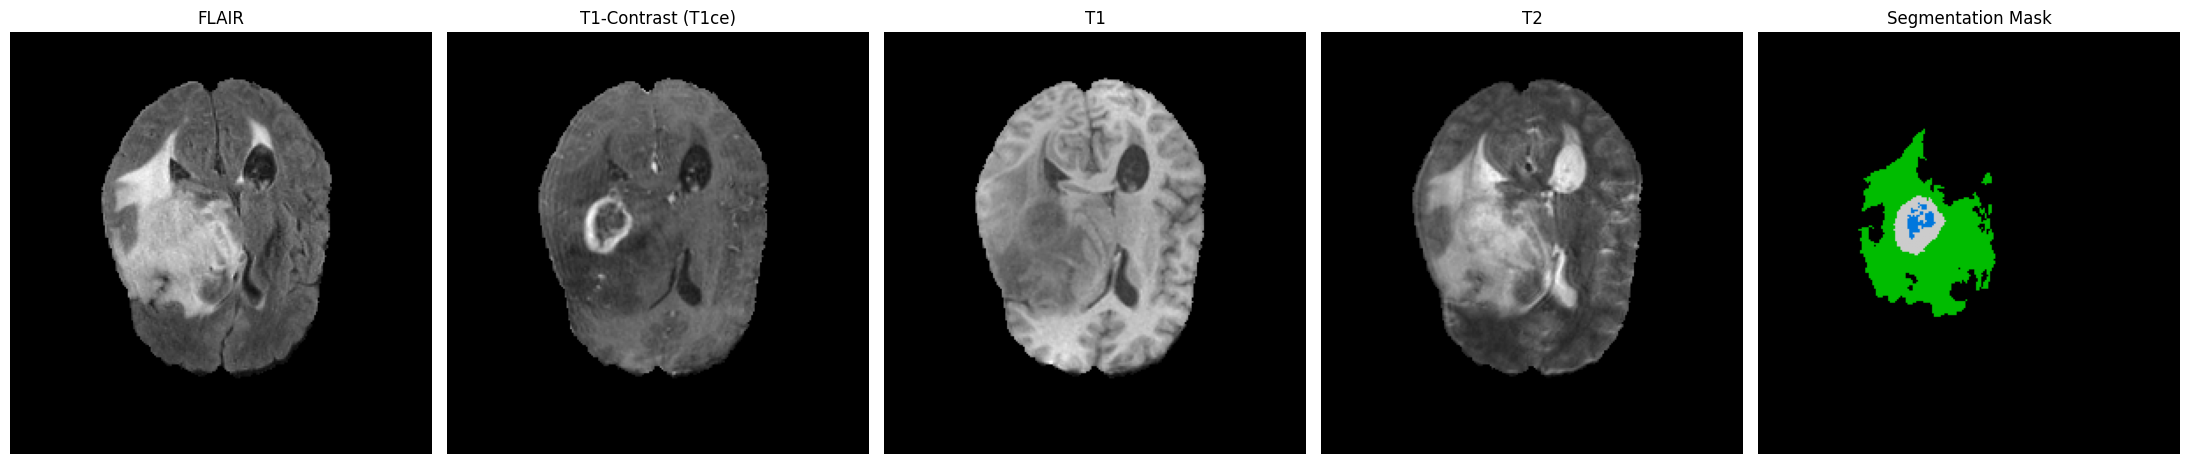

In [13]:
import os
import nibabel as nib
import matplotlib.pyplot as plt

# Grab the first patient from the previously loaded patient_folders list
p001 = patient_folders[0]

flair_path = os.path.join(p001, "BraTS20_Training_001_flair.nii")
t1ce_path  = os.path.join(p001, "BraTS20_Training_001_t1ce.nii")
t1_path    = os.path.join(p001, "BraTS20_Training_001_t1.nii")
t2_path    = os.path.join(p001, "BraTS20_Training_001_t2.nii")
seg_path   = os.path.join(p001, "BraTS20_Training_001_seg.nii")

# Extract axial slice 75 where the tumor is clearly visible
slice_idx = 75
flair = nib.load(flair_path).get_fdata()[:, :, slice_idx]
t1ce  = nib.load(t1ce_path).get_fdata()[:, :, slice_idx]
t1    = nib.load(t1_path).get_fdata()[:, :, slice_idx]
t2    = nib.load(t2_path).get_fdata()[:, :, slice_idx]
seg   = nib.load(seg_path).get_fdata()[:, :, slice_idx]

# Plot the 1x5 grid
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
titles = ['FLAIR', 'T1-Contrast (T1ce)', 'T1', 'T2', 'Segmentation Mask']
images = [flair, t1ce, t1, t2, seg]
cmaps  = ['gray', 'gray', 'gray', 'gray', 'nipy_spectral']

for i, ax in enumerate(axes):
    ax.imshow(images[i].T, cmap=cmaps[i], origin="lower")
    ax.set_title(titles[i], fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [14]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

def generate_full_volume_sanity_table(seg_nifti_path):
    """
    Evaluates the full 3D ground truth array against itself to establish 
    the absolute voxel counts (support) and verify pipeline integrity.
    """
    # Load the entire 3D volume (240x240x155)
    true_3d_mask = nib.load(seg_nifti_path).get_fdata().astype(np.int64)
    
    # Remap Label 4 to 3 to maintain consistent 0-3 class structure
    true_3d_mask[true_3d_mask == 4] = 3
    
    # Flatten the 3D volume into a 1D array of 8,928,000 voxels
    y_true = true_3d_mask.flatten()
    y_pred = y_true.copy() # Dummy perfect prediction for baseline
    
    class_names = [
        'Class 0: Background', 
        'Class 1: Necrotic Core (NCR)', 
        'Class 2: Edema (ED)', 
        'Class 3: Enhancing Tumor (ET)'
    ]
    
    report_dict = classification_report(
        y_true, y_pred, 
        labels=[0, 1, 2, 3], 
        target_names=class_names, 
        output_dict=True, 
        zero_division=0
    )
    
    df_report = pd.DataFrame(report_dict).transpose().round(4)
    df_report['support'] = df_report['support'].astype(int)
    
    return df_report

# Run the sanity check on Patient 001
sanity_check_table = generate_full_volume_sanity_table(seg_path)
display(sanity_check_table)

,precision,recall,f1-score,support
Class 0: Background,1.0,1.0,1.0,8716021
Class 1: Necrotic Core (NCR),1.0,1.0,1.0,15443
Class 2: Edema (ED),1.0,1.0,1.0,168794
Class 3: Enhancing Tumor (ET),1.0,1.0,1.0,27742
accuracy,1.0,1.0,1.0,1
macro avg,1.0,1.0,1.0,8928000
weighted avg,1.0,1.0,1.0,8928000
